<a href="https://colab.research.google.com/github/Richmiz/lung_cancer_model/blob/main/Lung_Cancer_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Dimensions: (59, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     59 non-null     object
 1   Surname  59 non-null     object
 2   Age      59 non-null     int64 
 3   Smokes   59 non-null     int64 
 4   AreaQ    59 non-null     int64 
 5   Alkhol   59 non-null     int64 
 6   Result   59 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 3.4+ KB
        Name      Surname  Age  Smokes  AreaQ  Alkhol  Result
0       John         Wick   35       3      5       4       1
1       John  Constantine   27      20      2       5       1
2     Camela     Anderson   30       0      5       2       0
3       Alex       Telles   28       0      8       1       0
4      Diego     Maradona   68       4      5       6       1
5  Cristiano      Ronaldo   34       0     10       0       0
6     Mihail          Tal   58      15     10       0

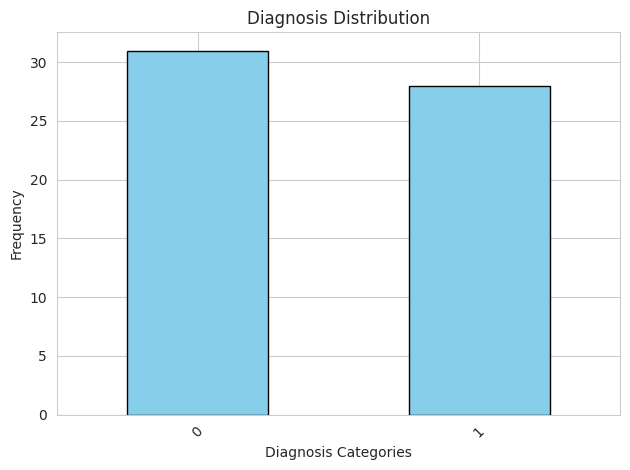


Plotting Pairwise Relationships:


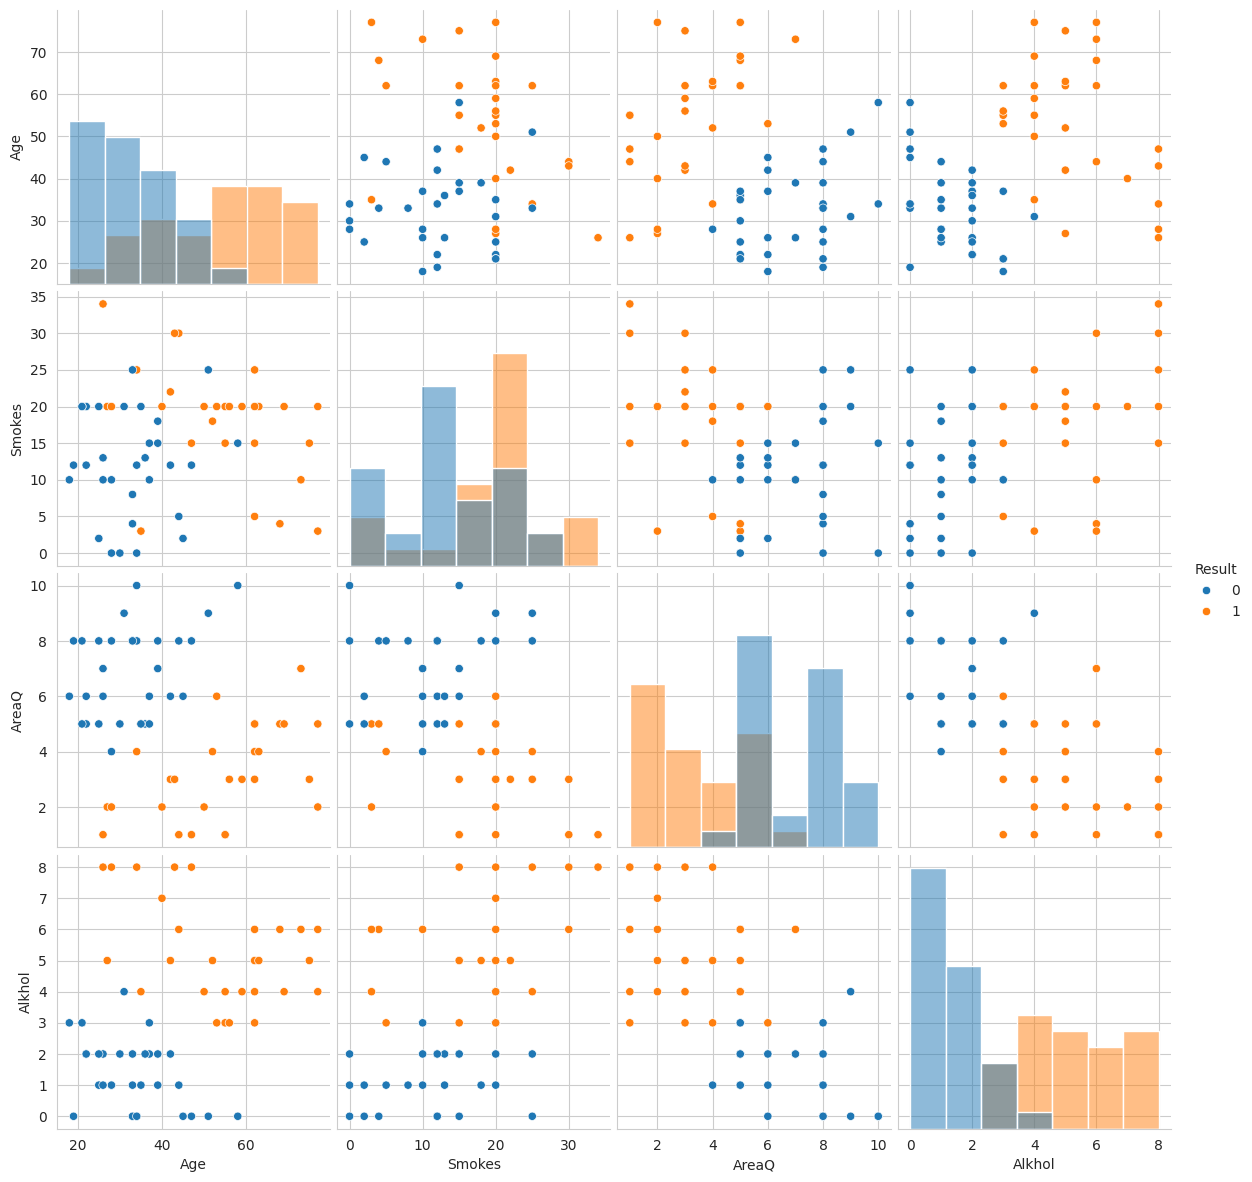


 Cleaning Data:
Dataset Dimensions after cleaning: (59, 5)
   Age  Smokes  AreaQ  Alkhol  Result
0   35       3      5       4       1
1   27      20      2       5       1
2   30       0      5       2       0
3   28       0      8       1       0
4   68       4      5       6       1

Splitting Data:
Training Data Shape (X_train, Y_train): (53, 4), (53,)
Training Data Shape (X_test, Y_test): (6, 4), (6,)

Training Logistic Regression Model:
Model Trained Successfully!

Evaluating Model Performance:
Predicted Values: [0 1 0 0 1 0]

Confusion Matrix:


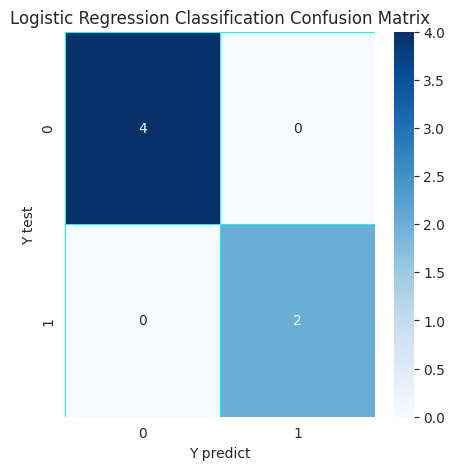

Logistec Regression Test Accuracy: 1.00


In [ ]:
from re import L
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

class LungCancerModel:
  def __init__(self, data_path):
    self.data_path = data_path
    self.data = None
    self.cleaned_data = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None
    self.model = LogisticRegression(C=10)


  def load_data(self):
    """"Load the Dataset"""
    self.data = pd.read_csv(self.data_path)
    print(f"Dataset Dimensions: {self.data.shape}")
    self.data.info()
    print(self.data.head(10))


  def visualize_data(self):
    """Visualize the distrubution of the diagnosis."""
    print("\nDaignosis Distribution: ")
    print(self.data["Result"].value_counts())
    self.data["Result"].value_counts()[0:30].plot(kind='bar', color='skyblue',
                                                  edgecolor='black')
    plt.title("Diagnosis Distribution")
    plt.xlabel("Diagnosis Categories")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


  def pairplot_features(self):
    """Create a pairplot for a features."""
    print("\nPlotting Pairwise Relationships:")
    sns.set_style("whitegrid")
    sns.pairplot(self.data, hue='Result', height=3, diag_kind="hist")
    plt.show()


  def clean_data(self):
    """Clean the dataset by removing unnecessary columns and handling missing values."""
    print("\n Cleaning Data:")
    self.cleaned_data = self.data.drop(columns=['Name', 'Surname'], axis=1)
    self.cleaned_data = self.cleaned_data.dropna(how='any')
    print(f"Dataset Dimensions after cleaning: {self.cleaned_data.shape}")
    print(self.cleaned_data.head())


  def split_data(self):
    """Split the dataset into training and testing sets."""
    print("\nSplitting Data:")
    X = self.cleaned_data.drop(columns=['Result'])
    Y = self.cleaned_data['Result']
    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, Y, test_size=0.1, random_state=9)
    print(f"Training Data Shape (X_train, Y_train): {self.X_train.shape}, {self.y_train.shape}")
    print(f"Training Data Shape (X_test, Y_test): {self.X_test.shape}, {self.y_test.shape}")


  def train_model(self):
    """Train the linear regression model on the training data."""
    print("\nTraining Logistic Regression Model:")
    self.model.fit(self.X_train, self.y_train)
    print("Model Trained Successfully!")


  def evaluate_model(self):
    """Evaluate the performance of the trained model on the testing data."""
    print("\nEvaluating Model Performance:")
    Y_predict = self.model.predict(self.X_test)
    print(f"Predicted Values: {Y_predict}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(self.y_test, Y_predict)
    f, ax = plt.subplots(figsize=(5, 5))
    sns.heatmap(cm, annot=True, linewidths=0.7, linecolor="cyan", fmt="g", ax=ax, cmap="Blues")
    plt.title("Logistic Regression Classification Confusion Matrix")
    plt.xlabel("Y predict")
    plt.ylabel("Y test")
    plt.show()

    # Test Score
    score = self.model.score(self.X_test, self.y_test)
    print(f"Logistec Regression Test Accuracy: {score:.2f}")



if __name__ == "__main__":
  model = LungCancerModel("../content/drive/MyDrive/Dataset_OOP/lung_cancer_examples.csv")
  model.load_data()
  model.visualize_data()
  model.pairplot_features()
  model.clean_data()
  model.split_data()
  model.train_model()
  model.evaluate_model()

Dataset Dimenssion : (59, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     59 non-null     object
 1   Surname  59 non-null     object
 2   Age      59 non-null     int64 
 3   Smokes   59 non-null     int64 
 4   AreaQ    59 non-null     int64 
 5   Alkhol   59 non-null     int64 
 6   Result   59 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 3.4+ KB
        Name      Surname  Age  Smokes  AreaQ  Alkhol  Result
0       John         Wick   35       3      5       4       1
1       John  Constantine   27      20      2       5       1
2     Camela     Anderson   30       0      5       2       0
3       Alex       Telles   28       0      8       1       0
4      Diego     Maradona   68       4      5       6       1
5  Cristiano      Ronaldo   34       0     10       0       0
6     Mihail          Tal   58      15     10       

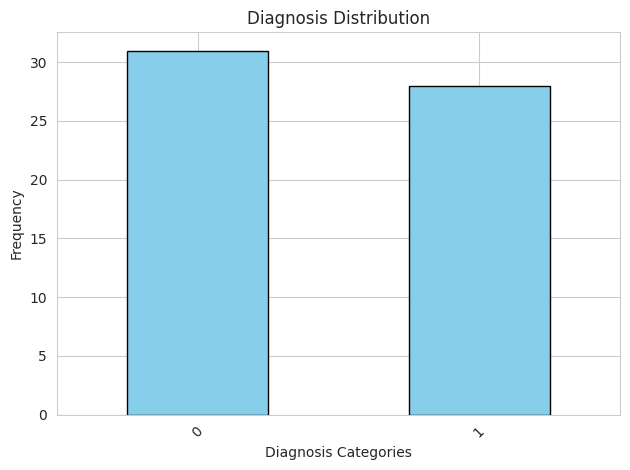


Plotting Pairwise Relationships:


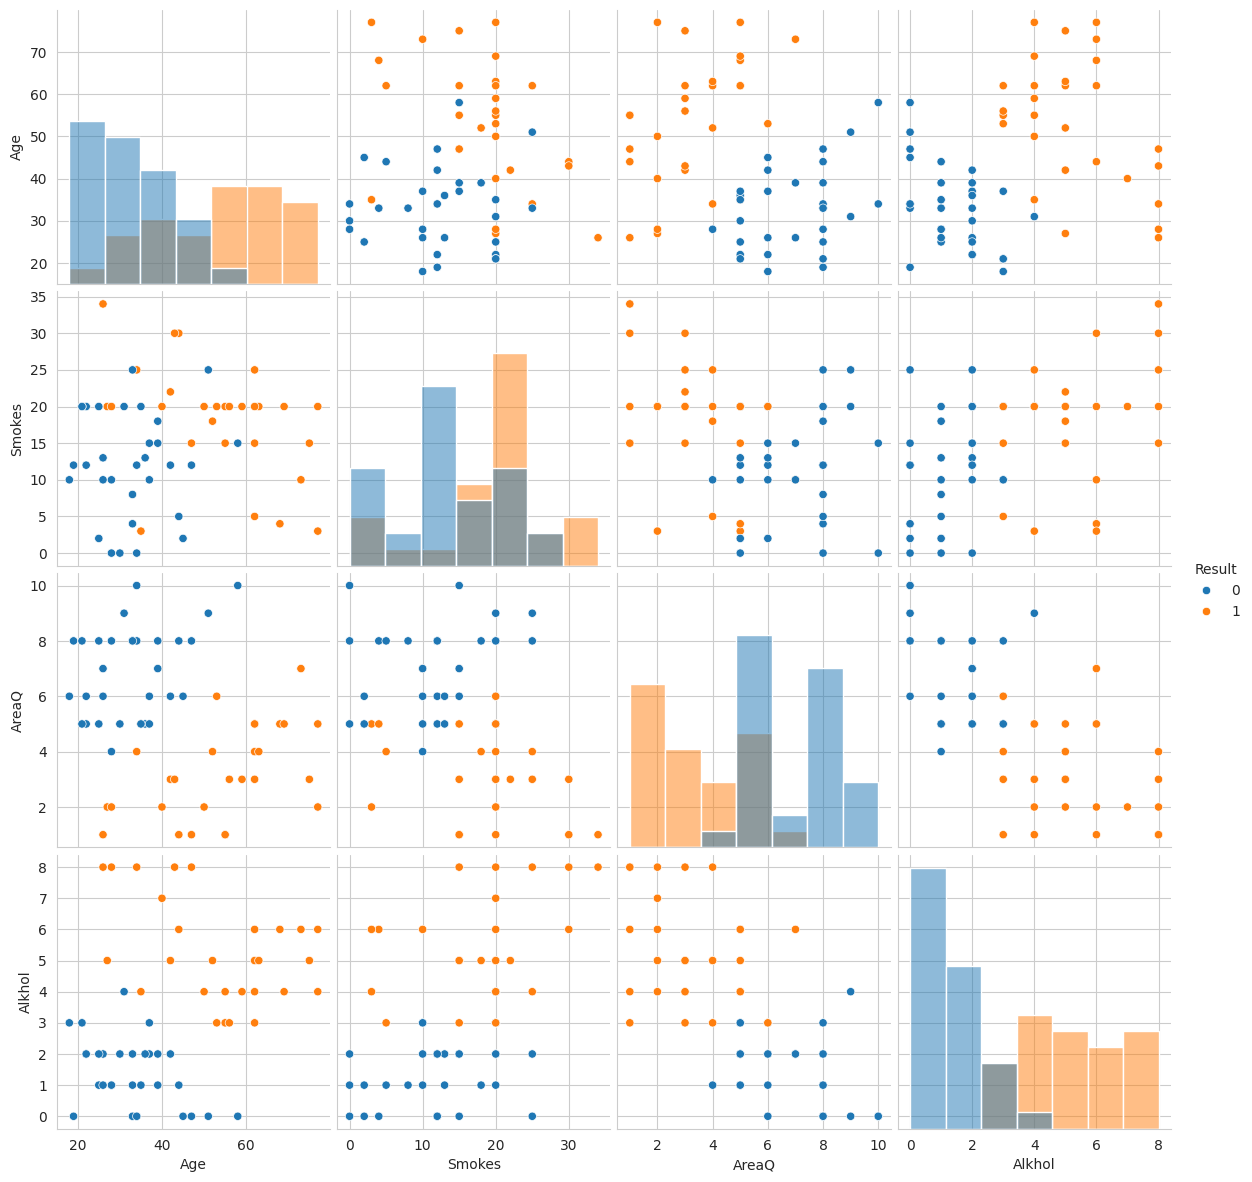


 Cleaning Data:
Dataset Dimensions after cleaning: (59, 5)
   Age  Smokes  AreaQ  Alkhol  Result
0   35       3      5       4       1
1   27      20      2       5       1
2   30       0      5       2       0
3   28       0      8       1       0
4   68       4      5       6       1

Splitting Data:
Training Data Shape (X_train, Y_train): (53, 4), (53,)
Training Data Shape (X_test, Y_test): (6, 4), (6,)

Training CNN Model:
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.4499 - loss: 0.6865 - val_accuracy: 0.3333 - val_loss: 0.6933
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6360 - loss: 0.6503 - val_accuracy: 0.5000 - val_loss: 0.6777
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6924 - loss: 0.6091 - val_accuracy: 0.6667 - val_loss: 0.6630
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5796 - loss: 0.6285 - val_accuracy: 0.6667 - val_loss: 0.6489
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7280 - loss: 0.5893 - val_accuracy: 0.6667 - val_loss: 0.6358
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8473 - loss: 0.5688 - val_accuracy: 0.6667 - val_loss: 0.6226
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8577 - loss: 0.5475 - val_accuracy: 0.6667 - val_loss: 0.6091
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8369 - loss: 0.5507 - val_accuracy: 0.8333 - val_loss: 0.5957
Epoch 9/10

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


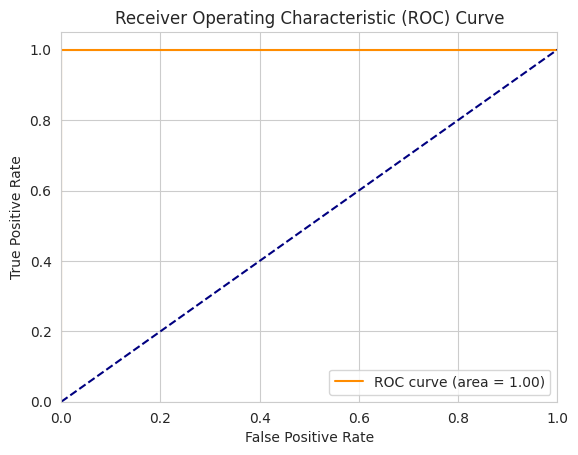

CNN AUC Score: 1.00

Confusion Matrix:


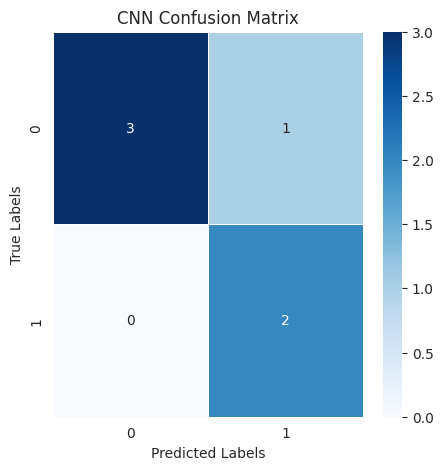


Evaluating CNN with ROC Curve and Confusion Matrix:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


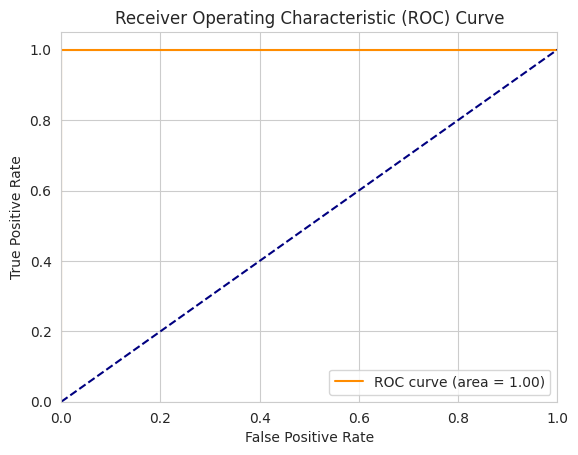

CNN AUC Score: 1.00

Confusion Matrix:


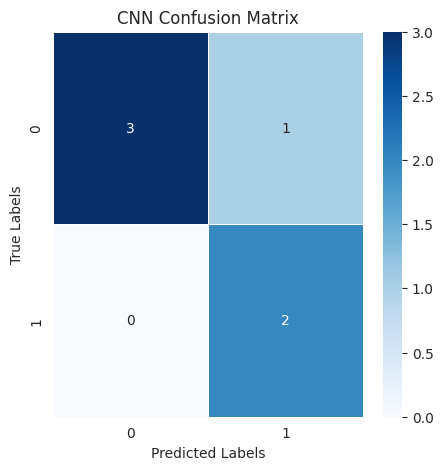

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, auc, roc_curve
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout


class LungCancerModel:
  def __init__(self, file_path):
    self.file_path = file_path
    self.data = None
    self.cleaned_data = None
    self.X_train, self.X_test = None, None
    self.y_train, self.y_test = None, None
    self.logistic_model = LogisticRegression(C=10)
    self.dt_model = DecisionTreeClassifier(random_state=9)
    self.svm_model = SVC(kernel='linear', C=1.0)
    self.knn_model = KNeighborsClassifier(n_neighbors=5)
    self.nb_model = GaussianNB()
    self.rf_model = RandomForestClassifier(n_estimators=100, random_state=9)
    self.cnn_model = None


  def load_data(self):
    """Load the dataset from the provided file path."""
    self.data = pd.read_csv(self.file_path)
    print(f"Dataset Dimenssion : {self.data.shape}")
    self.data.info()
    print(self.data.head(10))


  def visualize_data(self):
    """Visualize the diagnosis distribution."""
    print("\nDiagnosis Distribution:")
    result_count = self.data["Result"].value_counts()
    print(result_count)
    result_count.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Diagnosis Distribution")
    plt.xlabel("Diagnosis Categories")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

  def pairplot_features(self):
    """Create a pairplot for the features."""
    print("\nPlotting Pairwise Relationships:")
    sns.set_style("whitegrid")
    sns.pairplot(self.data, hue='Result', height=3, diag_kind="hist")
    plt.show()


  def clean_data(self):
    """Clean the dataset by removing unnecessary columns and handling missing values."""
    print("\n Cleaning Data:")
    self.cleaned_data = self.data.drop(columns=['Name', 'Surname'], errors='ignore').dropna()
    print(f"Dataset Dimensions after cleaning: {self.cleaned_data.shape}")
    print(self.cleaned_data.head())


  def split_data(self, test_size=0.1, random_state=9):
      """Split the dataset into training and testing sets."""
      print("\nSplitting Data:")
      X = self.cleaned_data.drop(columns=['Result'])
      Y = self.cleaned_data['Result']
      scaler = StandardScaler()
      X = scaler.fit_transform(X)
      self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state)
      print(f"Training Data Shape (X_train, Y_train): {self.X_train.shape}, {self.y_train.shape}")
      print(f"Training Data Shape (X_test, Y_test): {self.X_test.shape}, {self.y_test.shape}")


  def train_cnn_model(self):
    """Train the CNN model on the training data."""
    print("\nTraining CNN Model:")
    self.X_train_cnn = self.X_train.reshape(-1, self.X_train.shape[1], 1, 1)
    self.X_test_cnn = self.X_test.reshape(-1, self.X_test.shape[1], 1, 1)
    self.cnn_model = Sequential([
        Conv2D(32, (2, 1), activation='relu', input_shape=(self.X_train_cnn.shape[1], 1, 1)),
        MaxPooling2D((2, 1)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    self.cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    self.cnn_model.fit(self.X_train_cnn, self.y_train, epochs=10, batch_size=32, validation_data=(self.X_test_cnn, self.y_test))
    print("CNN Model Trained Successfully!")
    self.evaluate_cnn_with_roc_and_confusion_matrix()


  def evaluate_cnn_with_roc_and_confusion_matrix(self):
    """Evaluate CNN model and plot ROC curve and confusion matrix."""
    print("\nEvaluating CNN with ROC Curve and Confusion Matrix:")
    y_pred_prop = self.cnn_model.predict(self.X_test_cnn).ravel()
    y_pred_class = (y_pred_prop > 0.5).astype(int)
    fpr, tpr, _ = roc_curve(self.y_test, y_pred_prop)
    auc_score = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    print(f"CNN AUC Score: {auc_score:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(self.y_test, y_pred_class)
    print("\nConfusion Matrix:")
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", linewidths=0.7)
    plt.title("CNN Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()


if __name__ == "__main__":
  # File path to the dataset
  file_path = "../content/drive/MyDrive/Dataset_OOP/lung_cancer_examples.csv"
  lung_cancer_model = LungCancerModel(file_path)
  lung_cancer_model.load_data()
  lung_cancer_model.visualize_data()
  lung_cancer_model.pairplot_features()
  lung_cancer_model.clean_data()
  lung_cancer_model.split_data()
  lung_cancer_model.train_cnn_model()
  lung_cancer_model.evaluate_cnn_with_roc_and_confusion_matrix()
